In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
appli_train = pd.read_csv('application_train.csv')
appli_train

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


### BASIC CHECKS

In [3]:
appli_train.shape

(307511, 122)

In [4]:
appli_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
appli_train.tail()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
307510,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,0,0,0,0,0.0,0.0,0.0,2.0,0.0,1.0


In [6]:
appli_train.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [7]:
appli_train.describe(include='O')

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,WEEKDAY_APPR_PROCESS_START,ORGANIZATION_TYPE,FONDKAPREMONT_MODE,HOUSETYPE_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE
count,307511,307511,307511,307511,306219,307511,307511,307511,307511,211120,307511,307511,97216,153214,151170,161756
unique,2,3,2,2,7,8,5,6,6,18,7,58,4,3,7,2
top,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,Laborers,TUESDAY,Business Entity Type 3,reg oper account,block of flats,Panel,No
freq,278232,202448,202924,213312,248526,158774,218391,196432,272868,55186,53901,67992,73830,150503,66040,159428


In [8]:
appli_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [9]:
duplicate_count = appli_train.duplicated().sum()
duplicate_count

np.int64(0)

In [10]:
appli_train.select_dtypes(include=['int64','float64']).columns

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=106)

In [11]:
appli_train.select_dtypes(include=['O']).columns

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')

In [12]:
appli_train.isnull().sum()

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64

In [13]:
appli_train.isnull().sum().sort_values(ascending=False)

COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
COMMONAREA_MEDI             214865
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
                             ...  
FLAG_DOCUMENT_16                 0
FLAG_DOCUMENT_15                 0
FLAG_DOCUMENT_14                 0
FLAG_DOCUMENT_20                 0
FLAG_DOCUMENT_21                 0
Length: 122, dtype: int64

## EXPLORATORY DATA ANALYSIS

### Univariate Analysis

In [14]:
appli_train['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

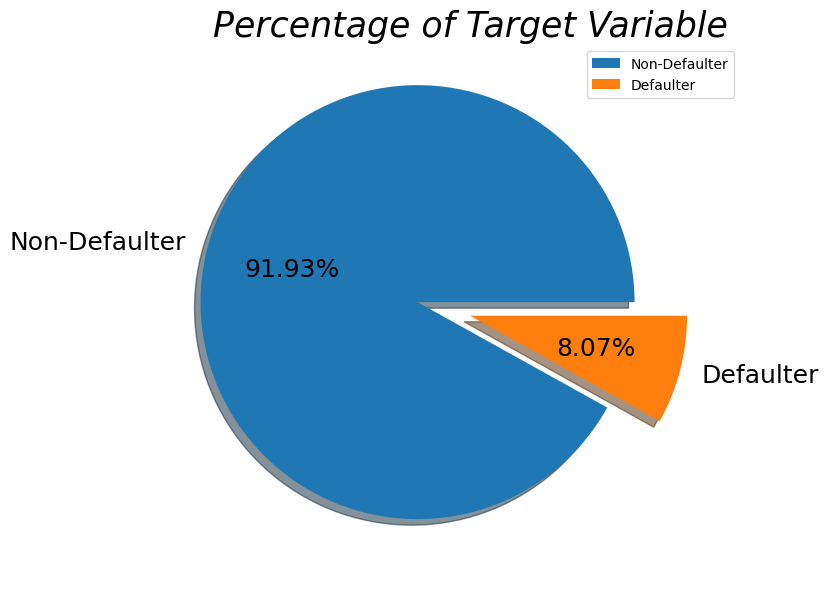

In [15]:
counts=appli_train['TARGET'].value_counts()
explode = [0.25,0]
plt.figure(figsize=(7,8))
plt.pie(counts, labels = counts.index.map({0: 'Non-Defaulter', 1: 'Defaulter'}),textprops = ({'fontsize':18}),explode =explode,autopct = '%1.2f%%',shadow = True,startangle=0,colors=None)
plt.legend()
plt.title('Percentage of Target Variable',fontsize=25, style = 'italic')
plt.show()

The chart shows that : 
- 91.93% people had a low risk of repaying the loans
- 8.07% people had a high risk due to not repaying

In [16]:
appli_train.NAME_CONTRACT_TYPE.unique()

array(['Cash loans', 'Revolving loans'], dtype=object)

In [17]:
appli_train.NAME_CONTRACT_TYPE.value_counts()

NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64

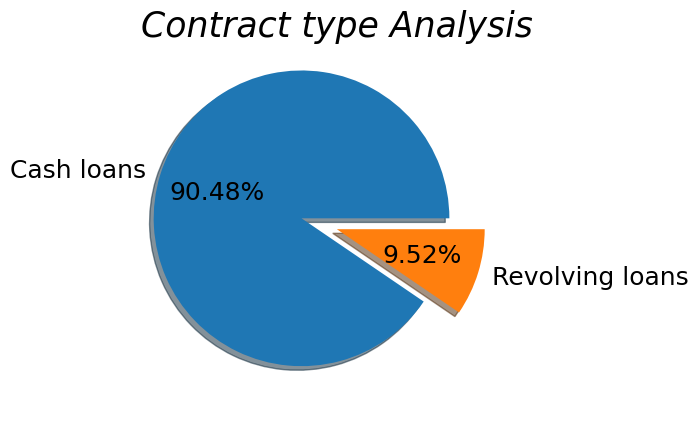

In [18]:
contract = appli_train['NAME_CONTRACT_TYPE'].value_counts()
explode = [0.25,0]
plt.pie(contract,labels = contract.index,textprops = {'fontsize':18},autopct = '%1.2f%%',explode = explode, shadow = True,startangle = 0,colors = None)
plt.title('Contract type Analysis',fontsize = 25,style = 'italic')
plt.show()

In [19]:
appli_train['CODE_GENDER'].unique()

array(['M', 'F', 'XNA'], dtype=object)

In [20]:
appli_train['CODE_GENDER'].value_counts()

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

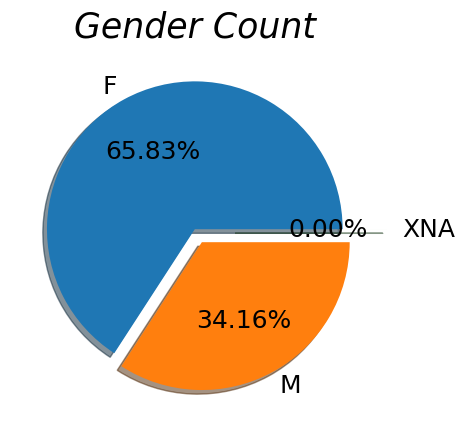

In [21]:
gender = appli_train['CODE_GENDER'].value_counts()
explode = [0,0.1,0.3]
plt.pie(gender,labels = gender.index,textprops = {'fontsize':18},autopct = '%1.2f%%',explode = explode, shadow = True,startangle = 0,colors = None)
plt.title('Gender Count',fontsize = 25,style = 'italic')
plt.show()

In [22]:
appli_train['FLAG_OWN_CAR'].unique()

array(['N', 'Y'], dtype=object)

In [23]:
appli_train['FLAG_OWN_CAR'].value_counts()

FLAG_OWN_CAR
N    202924
Y    104587
Name: count, dtype: int64

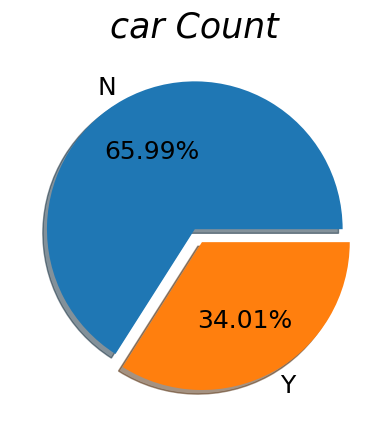

In [24]:
car = appli_train['FLAG_OWN_CAR'].value_counts()
explode = [0,0.1]
plt.pie(car,labels = car.index,textprops = {'fontsize':18},autopct = '%1.2f%%',explode = explode, shadow = True,startangle = 0,colors = None)
plt.title('car Count',fontsize = 25,style = 'italic')
plt.show()

In [25]:
appli_train.FLAG_OWN_REALTY.unique()

array(['Y', 'N'], dtype=object)

In [26]:
appli_train.FLAG_OWN_REALTY.value_counts()

FLAG_OWN_REALTY
Y    213312
N     94199
Name: count, dtype: int64

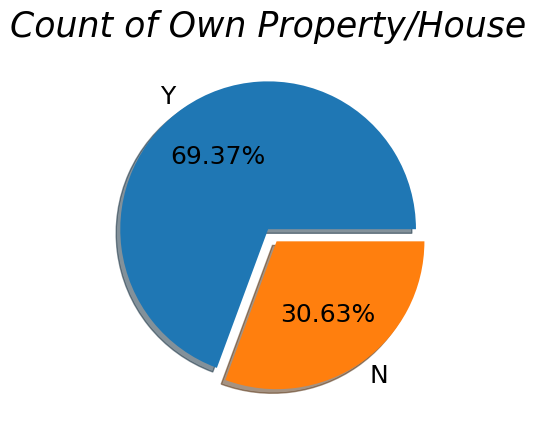

In [27]:
reality = appli_train['FLAG_OWN_REALTY'].value_counts()
explode = [0,0.1]
plt.pie(reality,labels = reality.index,textprops = {'fontsize':18},autopct = '%1.2f%%',explode = explode, shadow = True,startangle = 0,colors = None)
plt.title('Count of Own Property/House',fontsize = 25,style = 'italic')
plt.show()

## Bivariate Analysis

Here we take Target Column in Y-axis, remaining columns in x-axis to analyze the two variables

In [28]:
appli_train['NAME_TYPE_SUITE'].value_counts()

NAME_TYPE_SUITE
Unaccompanied      248526
Family              40149
Spouse, partner     11370
Children             3267
Other_B              1770
Other_A               866
Group of people       271
Name: count, dtype: int64

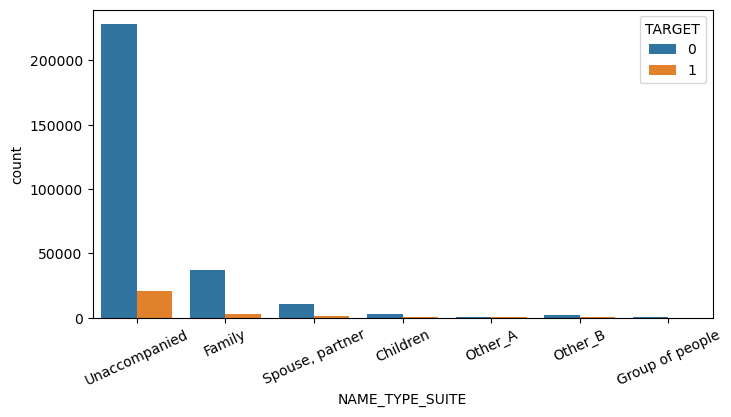

In [29]:
plt.figure(figsize=(8,4))
sns.countplot(x='NAME_TYPE_SUITE',data=appli_train,hue='TARGET')
plt.xticks(rotation=25)
plt.show()

In [30]:
appli_train['NAME_INCOME_TYPE'].value_counts()

NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

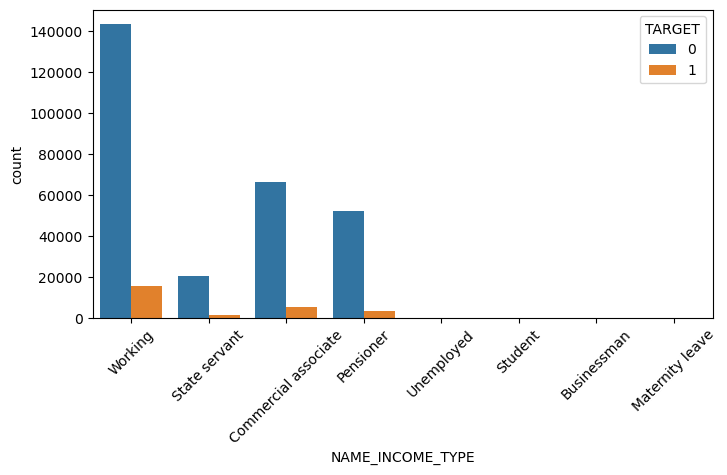

In [31]:
plt.figure(figsize=(8,4))
sns.countplot(x='NAME_INCOME_TYPE',data=appli_train,hue='TARGET')
plt.xticks(rotation=45)
plt.show()

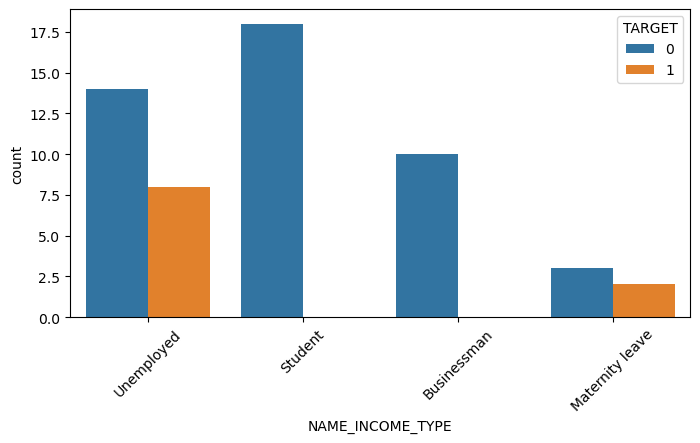

In [32]:
plt.figure(figsize=(8,4))
sns.countplot(x='NAME_INCOME_TYPE',data=appli_train[appli_train['NAME_INCOME_TYPE'].isin(['Unemployed','Student', 'Businessman','Maternity leave'])],hue='TARGET')
plt.xticks(rotation=45)
plt.show()

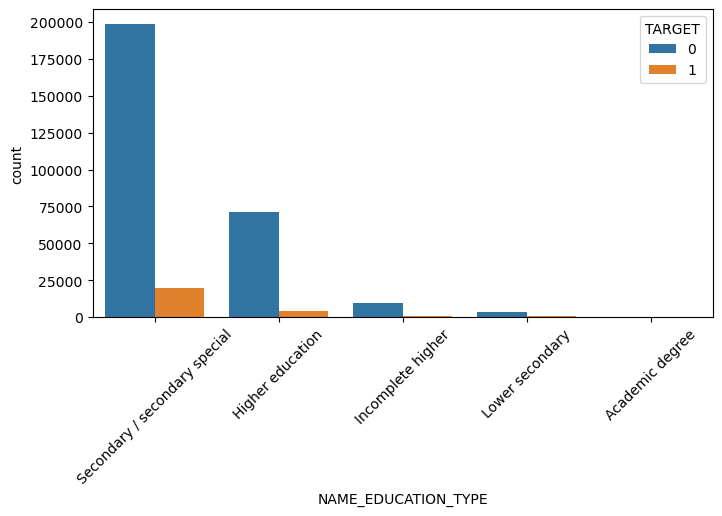

In [33]:
plt.figure(figsize=(8,4))
sns.countplot(x='NAME_EDUCATION_TYPE',data=appli_train,hue='TARGET')
plt.xticks(rotation=45)
plt.show()

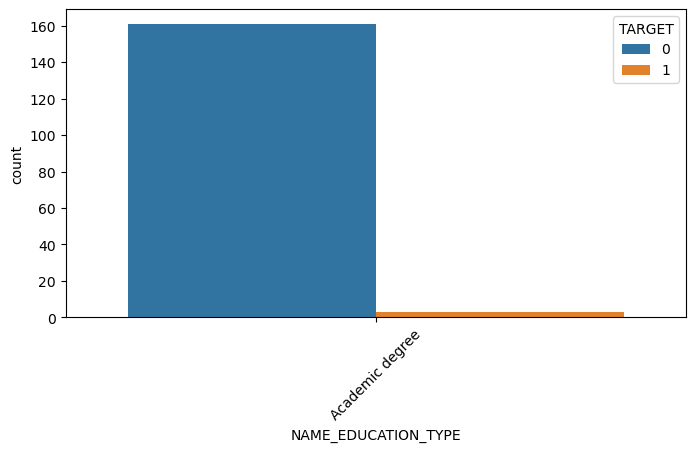

In [34]:
plt.figure(figsize=(8,4))
sns.countplot(x='NAME_EDUCATION_TYPE',data=appli_train[appli_train['NAME_EDUCATION_TYPE'].isin(['Academic degree'])],hue='TARGET')
plt.xticks(rotation=45)
plt.show()

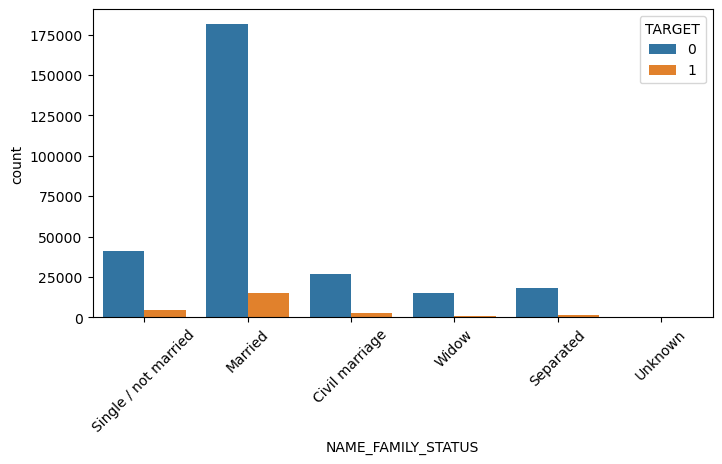

In [35]:
plt.figure(figsize=(8,4))
sns.countplot(x='NAME_FAMILY_STATUS',data=appli_train,hue='TARGET')
plt.xticks(rotation=45)
plt.show()

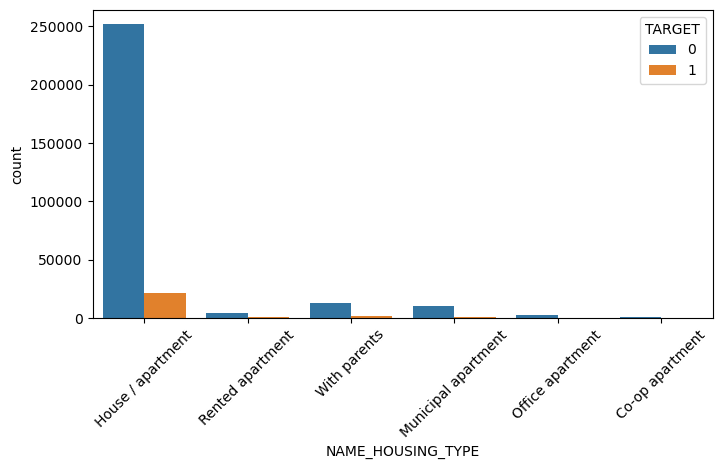

In [36]:
plt.figure(figsize=(8,4))
sns.countplot(x='NAME_HOUSING_TYPE',data=appli_train,hue='TARGET')
plt.xticks(rotation=45)
plt.show()

In [37]:
appli_train['AMT_INCOME_TOTAL'].unique()

array([202500. , 270000. ,  67500. , ...,  96768. , 546250.5, 113062.5])

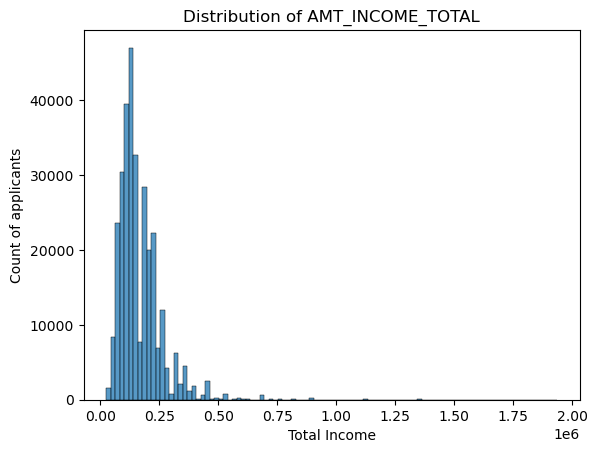

In [38]:
import seaborn as sns
filtered_data = appli_train[appli_train['AMT_INCOME_TOTAL'] < 2000000]
sns.histplot(data=filtered_data, x='AMT_INCOME_TOTAL', bins=100)
plt.xlabel('Total Income')
plt.ylabel('Count of applicants')
plt.title('Distribution of AMT_INCOME_TOTAL')
plt.show()

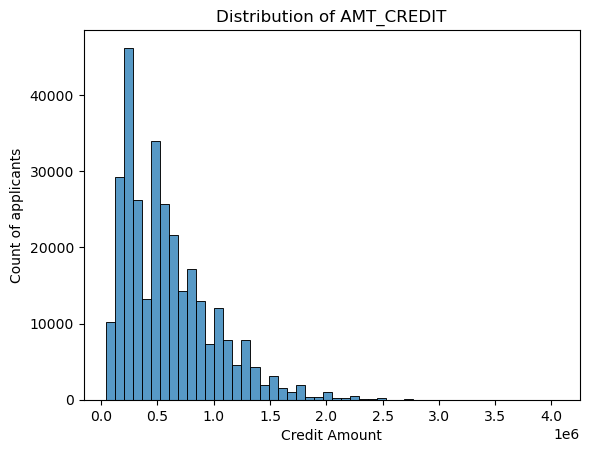

In [39]:
sns.histplot(appli_train['AMT_CREDIT'], bins=50)
plt.xlabel('Credit Amount')
plt.ylabel('Count of applicants')
plt.title('Distribution of AMT_CREDIT')
plt.show()

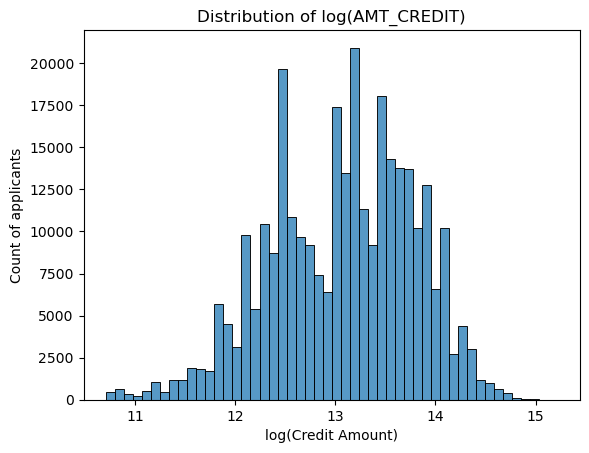

In [40]:
import numpy as np
sns.histplot(np.log(appli_train['AMT_CREDIT']), bins=50)
plt.xlabel('log(Credit Amount)')
plt.ylabel('Count of applicants')
plt.title('Distribution of log(AMT_CREDIT)')
plt.show()

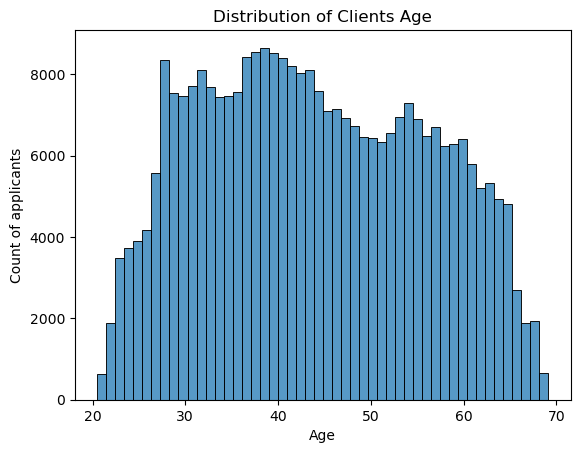

In [41]:
sns.histplot(appli_train['DAYS_BIRTH']/-365,bins=50)
plt.xlabel('Age')
plt.ylabel('Count of applicants')
plt.title('Distribution of Clients Age')
plt.show()

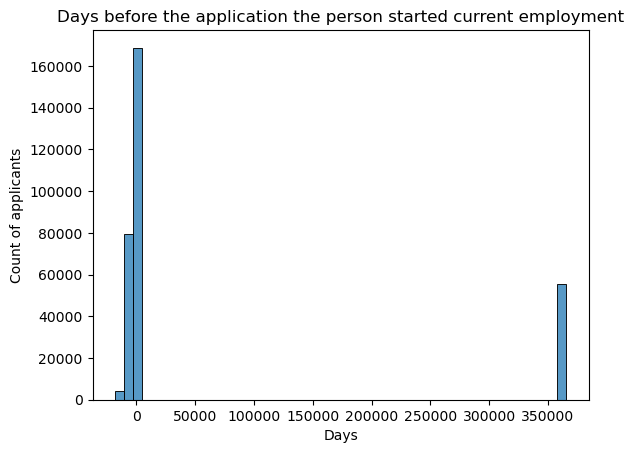

In [42]:
sns.histplot(appli_train['DAYS_EMPLOYED'], bins=50)
plt.xlabel('Days')
plt.ylabel('Count of applicants')
plt.title('Days before the application the person started current employment')
plt.show()

In [43]:
appli_train[appli_train['DAYS_EMPLOYED'] == 365243]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
8,100011,0,Cash loans,F,N,Y,0,112500.000,1019610.0,33826.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
11,100015,0,Cash loans,F,N,Y,0,38419.155,148365.0,10678.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0
23,100027,0,Cash loans,F,N,Y,0,83250.000,239850.0,23850.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
38,100045,0,Cash loans,F,N,Y,0,99000.000,247275.0,17338.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0
43,100050,0,Cash loans,F,N,Y,0,108000.000,746280.0,42970.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307469,456209,0,Cash loans,F,N,Y,0,202500.000,703728.0,29943.0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0
307483,456227,0,Cash loans,F,N,Y,0,99000.000,247275.0,16479.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,5.0
307487,456231,0,Cash loans,M,N,Y,0,117000.000,1071909.0,31473.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,8.0
307505,456249,0,Cash loans,F,N,Y,0,112500.000,225000.0,22050.0,...,0,0,0,0,0.0,0.0,0.0,2.0,0.0,0.0


In [44]:
appli_train['DAYS_EMPLOYED_ERROR'] = appli_train["DAYS_EMPLOYED"] == 365243
appli_train['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace = True)

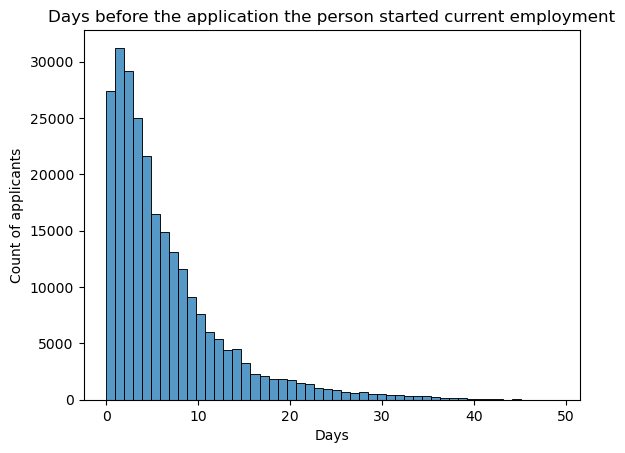

In [45]:
sns.histplot(appli_train['DAYS_EMPLOYED']/-365, bins=50)
plt.xlabel('Days')
plt.ylabel('Count of applicants')
plt.title('Days before the application the person started current employment')
plt.show()

## Data Preparation

In [46]:
appli_train['INCOME_GT_CREDIT_FLAG'] = appli_train['AMT_INCOME_TOTAL'] > appli_train['AMT_CREDIT']
appli_train['CREDIT_INCOME_PERCENT'] = appli_train['AMT_CREDIT'] / appli_train['AMT_INCOME_TOTAL']
appli_train['ANNUITY_INCOME_PERCENT'] = appli_train['AMT_ANNUITY'] / appli_train['AMT_INCOME_TOTAL']
appli_train['CREDIT_TERM'] = appli_train['AMT_CREDIT'] / appli_train['AMT_ANNUITY']
appli_train['DAYS_EMPLOYED_PERCENT'] = appli_train['DAYS_EMPLOYED'] / appli_train['DAYS_BIRTH']
print("The shape of application data:",appli_train.shape)

The shape of application data: (307511, 128)


In [47]:
bureau = pd.read_csv('bureau.csv')
bureau

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.00,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.00,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.50,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.00,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.00,NaN,NaN,0.0,Consumer credit,-21,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1716423,259355,5057750,Active,currency 1,-44,0,-30.0,NaN,0.0,0,11250.00,11250.0,0.0,0.0,Microloan,-19,NaN
1716424,100044,5057754,Closed,currency 1,-2648,0,-2433.0,-2493.0,5476.5,0,38130.84,0.0,0.0,0.0,Consumer credit,-2493,NaN
1716425,100044,5057762,Closed,currency 1,-1809,0,-1628.0,-970.0,NaN,0,15570.00,NaN,NaN,0.0,Consumer credit,-967,NaN
1716426,246829,5057770,Closed,currency 1,-1878,0,-1513.0,-1513.0,NaN,0,36000.00,0.0,0.0,0.0,Consumer credit,-1508,NaN


In [48]:
bureau_bal = pd.read_csv('bureau_balance.csv')
bureau_bal

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C
...,...,...,...
27209070,6670238,-64,0
27209071,6670238,-65,0
27209072,6670238,-66,0
27209073,6670238,-67,0


In [49]:
bureau_bal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27209075 entries, 0 to 27209074
Data columns (total 3 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   SK_ID_BUREAU    int64 
 1   MONTHS_BALANCE  int64 
 2   STATUS          object
dtypes: int64(2), object(1)
memory usage: 622.8+ MB


In [50]:
bureau_bal_numeric = bureau_bal.select_dtypes(include='number')
grp = bureau_bal_numeric.groupby('SK_ID_BUREAU').mean()
grp.reset_index(inplace=True)

In [51]:
grp.columns = ['BUREAU_BALANCE_'+column if column !='SK_ID_BUREAU' else column for column in grp.columns]
bureau = bureau.merge(grp, on='SK_ID_BUREAU', how='left')
bureau.update(bureau[grp.columns].fillna(0))

In [52]:
bureau_bal_categorical = pd.get_dummies(bureau_bal.select_dtypes('object'))
bureau_bal_categorical['SK_ID_BUREAU'] = bureau_bal['SK_ID_BUREAU']

In [53]:
grp = bureau_bal_categorical.groupby(by = ['SK_ID_BUREAU']).mean().reset_index()

In [54]:
grp.columns = ['BUREAU_BALANCE_'+column if column !='SK_ID_BUREAU' else column for column in grp.columns]
bureau = bureau.merge(grp, on='SK_ID_BUREAU', how='left')
bureau.update(bureau[grp.columns].fillna(0))

In [55]:
bureau

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,...,AMT_ANNUITY,BUREAU_BALANCE_MONTHS_BALANCE,BUREAU_BALANCE_STATUS_0,BUREAU_BALANCE_STATUS_1,BUREAU_BALANCE_STATUS_2,BUREAU_BALANCE_STATUS_3,BUREAU_BALANCE_STATUS_4,BUREAU_BALANCE_STATUS_5,BUREAU_BALANCE_STATUS_C,BUREAU_BALANCE_STATUS_X
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,...,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,...,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,...,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,...,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,...,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1716423,259355,5057750,Active,currency 1,-44,0,-30.0,NaN,0.0,0,...,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1716424,100044,5057754,Closed,currency 1,-2648,0,-2433.0,-2493.0,5476.5,0,...,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1716425,100044,5057762,Closed,currency 1,-1809,0,-1628.0,-970.0,NaN,0,...,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1716426,246829,5057770,Closed,currency 1,-1878,0,-1513.0,-1513.0,NaN,0,...,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [56]:
# Joining Bureau data to Application data
# Select numerical columns
bureau_numeric = bureau.select_dtypes(include='number')

# Group by 'SK_ID_CURR' and calculate the mean for each numerical feature
grp = bureau_numeric.drop(['SK_ID_BUREAU'], axis = 1).groupby('SK_ID_CURR').mean()

# Reset index
grp.reset_index(inplace=True)

In [57]:
grp.columns = ['BUREAU_'+column if column !='SK_ID_CURR' else column for column in grp.columns]
application_bureau = appli_train.merge(grp, on='SK_ID_CURR', how='left')
application_bureau.update(application_bureau[grp.columns].fillna(0))

In [58]:
bureau_categorical = pd.get_dummies(bureau.select_dtypes('object'))
bureau_categorical['SK_ID_CURR'] = bureau['SK_ID_CURR']

In [59]:
grp = bureau_categorical.groupby(by = ['SK_ID_CURR']).mean().reset_index()

In [60]:
grp.columns = ['BUREAU_'+column if column !='SK_ID_CURR' else column for column in grp.columns]
application_bureau = application_bureau.merge(grp, on='SK_ID_CURR', how='left')
application_bureau.update(application_bureau[grp.columns].fillna(0))

In [61]:
application_bureau.shape

(307511, 172)

In [62]:
application_bureau

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,BUREAU_CREDIT_TYPE_Interbank credit,BUREAU_CREDIT_TYPE_Loan for business development,BUREAU_CREDIT_TYPE_Loan for purchase of shares (margin lending),BUREAU_CREDIT_TYPE_Loan for the purchase of equipment,BUREAU_CREDIT_TYPE_Loan for working capital replenishment,BUREAU_CREDIT_TYPE_Microloan,BUREAU_CREDIT_TYPE_Mobile operator loan,BUREAU_CREDIT_TYPE_Mortgage,BUREAU_CREDIT_TYPE_Real estate loan,BUREAU_CREDIT_TYPE_Unknown type of loan
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [63]:
grp = bureau.groupby(by = ['SK_ID_CURR'])['SK_ID_BUREAU'].count().reset_index().rename(columns = {'SK_ID_BUREAU': 'BUREAU_LOAN_COUNT'})
application_bureau = application_bureau.merge(grp, on='SK_ID_CURR', how='left')

In [64]:
application_bureau['BUREAU_LOAN_COUNT'] = application_bureau['BUREAU_LOAN_COUNT'].fillna(0)

In [65]:
# Number of types of past loans per customer
grp = bureau[['SK_ID_CURR', 'CREDIT_TYPE']].groupby(by = ['SK_ID_CURR'])['CREDIT_TYPE'].nunique().reset_index().rename(columns={'CREDIT_TYPE': 'BUREAU_LOAN_TYPES'})
application_bureau = application_bureau.merge(grp, on='SK_ID_CURR', how='left')

In [66]:
application_bureau['BUREAU_LOAN_TYPES'] = application_bureau['BUREAU_LOAN_TYPES'].fillna(0)

In [67]:
# Debt over credit ratio
bureau['AMT_CREDIT_SUM'] = bureau['AMT_CREDIT_SUM'].fillna(0)
bureau['AMT_CREDIT_SUM_DEBT'] = bureau['AMT_CREDIT_SUM_DEBT'].fillna(0)

In [68]:
grp1 = bureau[['SK_ID_CURR','AMT_CREDIT_SUM']].groupby(by=['SK_ID_CURR'])['AMT_CREDIT_SUM'].sum().reset_index().rename(columns={'AMT_CREDIT_SUM': 'TOTAL_CREDIT_SUM'})

In [69]:
grp2 = bureau[['SK_ID_CURR','AMT_CREDIT_SUM_DEBT']].groupby(by=['SK_ID_CURR'])['AMT_CREDIT_SUM_DEBT'].sum().reset_index().rename(columns={'AMT_CREDIT_SUM_DEBT':'TOTAL_CREDIT_SUM_DEBT'})

In [70]:
grp1['DEBT_CREDIT_RATIO'] = grp2['TOTAL_CREDIT_SUM_DEBT']/grp1['TOTAL_CREDIT_SUM']
del grp1['TOTAL_CREDIT_SUM']

In [71]:
application_bureau = application_bureau.merge(grp1, on='SK_ID_CURR', how='left')

In [72]:
application_bureau['DEBT_CREDIT_RATIO'] = application_bureau['DEBT_CREDIT_RATIO'].fillna(0)
application_bureau['DEBT_CREDIT_RATIO'].replace([np.inf, -np.inf], 0, inplace=True)
application_bureau['DEBT_CREDIT_RATIO'] = pd.to_numeric(application_bureau['DEBT_CREDIT_RATIO'], downcast='float')

In [73]:
# Overdue over debt ratio
bureau['AMT_CREDIT_SUM_OVERDUE'] = bureau['AMT_CREDIT_SUM_OVERDUE'].fillna(0)
bureau['AMT_CREDIT_SUM_DEBT'] = bureau['AMT_CREDIT_SUM_DEBT'].fillna(0)

In [74]:
grp1 = bureau[['SK_ID_CURR','AMT_CREDIT_SUM_OVERDUE']].groupby(by=['SK_ID_CURR'])['AMT_CREDIT_SUM_OVERDUE'].sum().reset_index().rename(columns={'AMT_CREDIT_SUM_OVERDUE': 'TOTAL_CUSTOMER_OVERDUE'})
grp2 = bureau[['SK_ID_CURR','AMT_CREDIT_SUM_DEBT']].groupby(by=['SK_ID_CURR'])['AMT_CREDIT_SUM_DEBT'].sum().reset_index().rename(columns={'AMT_CREDIT_SUM_DEBT':'TOTAL_CUSTOMER_DEBT'})

In [75]:
grp1['OVERDUE_DEBT_RATIO'] = grp1['TOTAL_CUSTOMER_OVERDUE']/grp2['TOTAL_CUSTOMER_DEBT']
del grp1['TOTAL_CUSTOMER_OVERDUE']

In [76]:
application_bureau = application_bureau.merge(grp1, on='SK_ID_CURR', how='left')

In [77]:
application_bureau['OVERDUE_DEBT_RATIO'] = application_bureau['OVERDUE_DEBT_RATIO'].fillna(0)
application_bureau.replace([np.inf, -np.inf], 0,inplace=True)

In [78]:
application_bureau['OVERDUE_DEBT_RATIO'] = pd.to_numeric(application_bureau['OVERDUE_DEBT_RATIO'], downcast='float')

## Using Previous Application Data

In [79]:
previous_applicaton = pd.read_csv('previous_application.csv')

In [80]:
previous_applicaton

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1670209,2300464,352015,Consumer loans,14704.290,267295.5,311400.0,0.0,267295.5,WEDNESDAY,12,...,Furniture,30.0,low_normal,POS industry with interest,365243.0,-508.0,362.0,-358.0,-351.0,0.0
1670210,2357031,334635,Consumer loans,6622.020,87750.0,64291.5,29250.0,87750.0,TUESDAY,15,...,Furniture,12.0,middle,POS industry with interest,365243.0,-1604.0,-1274.0,-1304.0,-1297.0,0.0
1670211,2659632,249544,Consumer loans,11520.855,105237.0,102523.5,10525.5,105237.0,MONDAY,12,...,Consumer electronics,10.0,low_normal,POS household with interest,365243.0,-1457.0,-1187.0,-1187.0,-1181.0,0.0
1670212,2785582,400317,Cash loans,18821.520,180000.0,191880.0,NaN,180000.0,WEDNESDAY,9,...,XNA,12.0,low_normal,Cash X-Sell: low,365243.0,-1155.0,-825.0,-825.0,-817.0,1.0


Joining Previous Application data with Application Bureau data

In [81]:
# Number of previous applications per customer
grp = previous_applicaton[['SK_ID_CURR','SK_ID_PREV']].groupby(by=['SK_ID_CURR'])['SK_ID_PREV'].count().reset_index().rename(columns={'SK_ID_PREV':'PREV_APP_COUNT'})
application_bureau_prev = application_bureau.merge(grp, on =['SK_ID_CURR'], how = 'left')
application_bureau_prev['PREV_APP_COUNT'] = application_bureau_prev['PREV_APP_COUNT'].fillna(0)

In [82]:
# Select numerical columns
prev_numeric = previous_applicaton.select_dtypes(include='number')

# Group by 'SK_ID_CURR' and calculate the mean for each numerical feature
grp = prev_numeric.drop(['SK_ID_PREV'], axis = 1).groupby('SK_ID_CURR').mean()

# Reset index
grp.reset_index(inplace=True)

In [83]:
# Combining categorical features
prev_categorical = pd.get_dummies(previous_applicaton.select_dtypes('object'))
prev_categorical['SK_ID_CURR'] = previous_applicaton['SK_ID_CURR']
prev_categorical.head()

,NAME_CONTRACT_TYPE_Cash loans,NAME_CONTRACT_TYPE_Consumer loans,NAME_CONTRACT_TYPE_Revolving loans,NAME_CONTRACT_TYPE_XNA,WEEKDAY_APPR_PROCESS_START_FRIDAY,WEEKDAY_APPR_PROCESS_START_MONDAY,WEEKDAY_APPR_PROCESS_START_SATURDAY,WEEKDAY_APPR_PROCESS_START_SUNDAY,WEEKDAY_APPR_PROCESS_START_THURSDAY,WEEKDAY_APPR_PROCESS_START_TUESDAY,...,PRODUCT_COMBINATION_Cash X-Sell: middle,PRODUCT_COMBINATION_POS household with interest,PRODUCT_COMBINATION_POS household without interest,PRODUCT_COMBINATION_POS industry with interest,PRODUCT_COMBINATION_POS industry without interest,PRODUCT_COMBINATION_POS mobile with interest,PRODUCT_COMBINATION_POS mobile without interest,PRODUCT_COMBINATION_POS other with interest,PRODUCT_COMBINATION_POS others without interest,SK_ID_CURR
0,False,True,False,False,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,271877
1,True,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,108129
2,True,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,122040
3,True,False,False,False,False,True,False,False,False,False,...,True,False,False,False,False,False,False,False,False,176158
4,True,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,202054


In [84]:
grp = prev_categorical.groupby('SK_ID_CURR').mean().reset_index()
grp.columns = ['PREV_'+column if column != 'SK_ID_CURR' else column for column in grp.columns]

In [85]:
application_bureau_prev = application_bureau_prev.merge(grp, on=['SK_ID_CURR'], how='left')
application_bureau_prev.update(application_bureau_prev[grp.columns].fillna(0))

## Using POS_CASH_balance data:

In [86]:
pos_cash = pd.read_csv('POS_CASH_balance.csv')

In [87]:
pos_cash

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0.0,0.0
1,1715348,367990,-33,36.0,35.0,Active,0.0,0.0
2,1784872,397406,-32,12.0,9.0,Active,0.0,0.0
3,1903291,269225,-35,48.0,42.0,Active,0.0,0.0
4,2341044,334279,-35,36.0,35.0,Active,0.0,0.0
...,...,...,...,...,...,...,...,...
8118344,2445615,345496,-21,48.0,45.0,Active,0.0,0.0
8118345,2277900,286131,-18,24.0,3.0,Active,0.0,0.0
8118346,1087377,113319,-35,36.0,35.0,Active,0.0,0.0
8118347,2057862,374612,-37,24.0,19.0,Active,0.0,0.0


Joining POS_CASH_balance data to application_bureau_prev_data:

In [88]:
# Combining numerical features
# Select numerical columns
pos_numeric = pos_cash.select_dtypes(include='number')

# Group by 'SK_ID_CURR' and calculate the mean for each numerical feature
grp = pos_numeric.drop(['SK_ID_PREV'], axis = 1).groupby('SK_ID_CURR').mean()

# Reset index
grp.reset_index(inplace=True)

In [89]:
prev_columns = ['POS_'+column if column != 'SK_ID_CURR' else column for column in grp.columns ]

In [90]:
grp.columns = prev_columns
application_bureau_prev = application_bureau_prev.merge(grp, on =['SK_ID_CURR'], how = 'left')

In [91]:
application_bureau_prev.update(application_bureau_prev[grp.columns].fillna(0))

In [92]:
# Combining categorical features
pos_cash_categorical = pd.get_dummies(pos_cash.select_dtypes('object'))
pos_cash_categorical['SK_ID_CURR'] = pos_cash['SK_ID_CURR']

In [93]:
grp = pos_cash_categorical.groupby('SK_ID_CURR').mean().reset_index()
grp.columns = ['POS_'+column if column != 'SK_ID_CURR' else column for column in grp.columns]

In [94]:
application_bureau_prev = application_bureau_prev.merge(grp, on=['SK_ID_CURR'], how='left')
application_bureau_prev.update(application_bureau_prev[grp.columns].fillna(0))

## Using installments_payments data:

In [95]:
insta_payments = pd.read_csv('installments_payments.csv')

In [96]:
insta_payments

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674.0,1.0,6.0,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639.0,0.0,34.0,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053.0,2.0,1.0,-63.0,-63.0,25425.000,25425.000
3,2452527,199697.0,1.0,3.0,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756.0,1.0,2.0,-1383.0,-1366.0,2165.040,2160.585
...,...,...,...,...,...,...,...,...
8326050,2797273,343566.0,1.0,7.0,-942.0,-946.0,11516.670,11516.670
8326051,1826095,349506.0,1.0,7.0,-1279.0,-1289.0,6783.795,6783.795
8326052,1159652,322610.0,1.0,11.0,-705.0,-730.0,16545.960,16545.960
8326053,2253254,313353.0,0.0,28.0,-1008.0,-1008.0,19294.515,19294.515


In [97]:
insta_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8326055 entries, 0 to 8326054
Data columns (total 8 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_PREV              int64  
 1   SK_ID_CURR              float64
 2   NUM_INSTALMENT_VERSION  float64
 3   NUM_INSTALMENT_NUMBER   float64
 4   DAYS_INSTALMENT         float64
 5   DAYS_ENTRY_PAYMENT      float64
 6   AMT_INSTALMENT          float64
 7   AMT_PAYMENT             float64
dtypes: float64(7), int64(1)
memory usage: 508.2 MB


combining with main data

In [98]:
# Combining numerical features and there are no categorical features in this dataset
grp = insta_payments.drop('SK_ID_PREV', axis =1).groupby(by=['SK_ID_CURR']).mean().reset_index()

In [99]:
prev_columns = ['INSTA_'+column if column != 'SK_ID_CURR' else column for column in grp.columns ]

In [100]:
grp.columns = prev_columns

In [101]:
application_bureau_prev = application_bureau_prev.merge(grp, on =['SK_ID_CURR'], how = 'left')

In [102]:
application_bureau_prev.update(application_bureau_prev[grp.columns].fillna(0))

## Using Credit card balance data:

In [103]:
credit_card = pd.read_csv('credit_card_balance.csv')
credit_card

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1.0,0.0,1.0,35.0,Active,0.0,0.0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1.0,0.0,0.0,69.0,Active,0.0,0.0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0.0,0.0,0.0,30.0,Active,0.0,0.0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1.0,0.0,0.0,10.0,Active,0.0,0.0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1.0,0.0,1.0,101.0,Active,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3265438,2211186,420883,-14,184731.255,450000,18000.0,18000.0,0.0,0.0,7910.325,...,178725.600,178725.600,3.0,3.0,0.0,0.0,8.0,Active,0.0,0.0
3265439,1954127,132161,-9,305970.975,495000,67500.0,67500.0,0.0,0.0,11779.020,...,299243.475,299243.475,5.0,5.0,0.0,0.0,15.0,Active,0.0,0.0
3265440,1845993,311223,-7,10280.340,90000,0.0,0.0,0.0,0.0,2250.000,...,10280.340,10280.340,0.0,0.0,0.0,0.0,17.0,Active,0.0,0.0
3265441,1043448,385351,-14,465364.710,450000,0.0,0.0,0.0,0.0,23306.355,...,461825.235,461825.235,0.0,0.0,0.0,0.0,16.0,Active,0.0,0.0


In [104]:
credit_card.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3265443 entries, 0 to 3265442
Data columns (total 23 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   SK_ID_PREV                  int64  
 1   SK_ID_CURR                  int64  
 2   MONTHS_BALANCE              int64  
 3   AMT_BALANCE                 float64
 4   AMT_CREDIT_LIMIT_ACTUAL     int64  
 5   AMT_DRAWINGS_ATM_CURRENT    float64
 6   AMT_DRAWINGS_CURRENT        float64
 7   AMT_DRAWINGS_OTHER_CURRENT  float64
 8   AMT_DRAWINGS_POS_CURRENT    float64
 9   AMT_INST_MIN_REGULARITY     float64
 10  AMT_PAYMENT_CURRENT         float64
 11  AMT_PAYMENT_TOTAL_CURRENT   float64
 12  AMT_RECEIVABLE_PRINCIPAL    float64
 13  AMT_RECIVABLE               float64
 14  AMT_TOTAL_RECEIVABLE        float64
 15  CNT_DRAWINGS_ATM_CURRENT    float64
 16  CNT_DRAWINGS_CURRENT        float64
 17  CNT_DRAWINGS_OTHER_CURRENT  float64
 18  CNT_DRAWINGS_POS_CURRENT    float64
 19  CNT_INSTALMENT_MATURE

combining with main data

In [105]:
# Select numerical columns
credit_numeric = credit_card.select_dtypes(include='number')

# Group by 'SK_ID_CURR' and calculate the mean for each numerical feature
grp = credit_numeric.drop(['SK_ID_PREV'], axis = 1).groupby('SK_ID_CURR').mean()

# Reset index
grp.reset_index(inplace=True)

In [106]:
prev_columns = ['CREDIT_'+column if column != 'SK_ID_CURR' else column for column in grp.columns ]

In [107]:
grp.columns = prev_columns
application_bureau_prev = application_bureau_prev.merge(grp, on =['SK_ID_CURR'], how = 'left')

In [108]:
application_bureau_prev.update(application_bureau_prev[grp.columns].fillna(0))

In [109]:
# Combining categorical features
credit_categorical = pd.get_dummies(credit_card.select_dtypes('object'))
credit_categorical['SK_ID_CURR'] = credit_card['SK_ID_CURR']

In [110]:
grp = credit_categorical.groupby('SK_ID_CURR').mean().reset_index()
grp.columns = ['CREDIT_'+column if column != 'SK_ID_CURR' else column for column in grp.columns]

In [111]:
application_bureau_prev = application_bureau_prev.merge(grp, on=['SK_ID_CURR'], how='left')
application_bureau_prev.update(application_bureau_prev[grp.columns].fillna(0))

In [112]:
application_bureau_prev.shape

(307511, 367)

In [113]:
application_bureau_prev

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,CREDIT_CNT_INSTALMENT_MATURE_CUM,CREDIT_SK_DPD,CREDIT_SK_DPD_DEF,CREDIT_NAME_CONTRACT_STATUS_Active,CREDIT_NAME_CONTRACT_STATUS_Approved,CREDIT_NAME_CONTRACT_STATUS_Completed,CREDIT_NAME_CONTRACT_STATUS_Demand,CREDIT_NAME_CONTRACT_STATUS_Refused,CREDIT_NAME_CONTRACT_STATUS_Sent proposal,CREDIT_NAME_CONTRACT_STATUS_Signed
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Dividing the data for model creation

In [114]:
X=application_bureau_prev.drop(['TARGET','SK_ID_CURR'],axis=1)
y=application_bureau_prev['TARGET']

In [115]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,stratify=y)

In [116]:
X_train.shape

(230633, 365)

In [117]:
X_test.shape

(76878, 365)

In [118]:
# Seperation of columns into numeric and categorical columns
types = np.array([dt for dt in X_train.dtypes])

In [119]:
types

array([dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('int64'),
       dtype('float64'), dtype('float64'), dtype('float64'),
       dtype('float64'), dtype('O'), dtype('O'), dtype('O'), dtype('O'),
       dtype('O'), dtype('float64'), dtype('int64'), dtype('float64'),
       dtype('float64'), dtype('int64'), dtype('float64'), dtype('int64'),
       dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'),
       dtype('int64'), dtype('O'), dtype('float64'), dtype('int64'),
       dtype('int64'), dtype('O'), dtype('int64'), dtype('int64'),
       dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'),
       dtype('int64'), dtype('O'), dtype('float64'), dtype('float64'),
       dtype('float64'), dtype('float64'), dtype('float64'),
       dtype('float64'), dtype('float64'), dtype('float64'),
       dtype('float64'), dtype('float64'), dtype('float64'),
       dtype('float64'), dtype('float64'), dtype('float64'),
       dtype('float64'), dtype('float64'), dtype('float6

In [120]:
all_columns = X_train.columns.values
is_num = types != 'object'

In [121]:
num_cols = all_columns[is_num]
cat_cols = all_columns[~is_num]

In [122]:
from sklearn.impute import SimpleImputer
# Featurization of numeric data
imputer_num = SimpleImputer(strategy='median')
X_train_num = imputer_num.fit_transform(X_train[num_cols])
X_test_num = imputer_num.transform(X_test[num_cols])

In [123]:
from sklearn.preprocessing import StandardScaler

scaler_num = StandardScaler()
X_train_num1 = scaler_num.fit_transform(X_train_num)
X_test_num1 = scaler_num.transform(X_test_num)

In [124]:
X_train_num_final = pd.DataFrame(X_train_num1, columns=num_cols)
X_test_num_final = pd.DataFrame(X_test_num1, columns=num_cols)

In [125]:
# Featurization of categorical data
imputer_cat = SimpleImputer(strategy='constant', fill_value='MISSING')
X_train_cat = imputer_cat.fit_transform(X_train[cat_cols])
X_test_cat = imputer_cat.transform(X_test[cat_cols])

In [126]:
X_train_cat1= pd.DataFrame(X_train_cat, columns=cat_cols)
X_test_cat1= pd.DataFrame(X_test_cat, columns=cat_cols)

In [127]:
from sklearn.preprocessing import OneHotEncoder
import warnings
warnings.filterwarnings("ignore")

ohe = OneHotEncoder(sparse_output=False,handle_unknown='ignore')
X_train_cat2 = ohe.fit_transform(X_train_cat1)
X_test_cat2 = ohe.transform(X_test_cat1)

In [128]:
cat_cols_ohe = ohe.get_feature_names_out(input_features=cat_cols)

In [129]:
X_train_cat_final = pd.DataFrame(X_train_cat2, columns = cat_cols_ohe)
X_test_cat_final = pd.DataFrame(X_test_cat2, columns = cat_cols_ohe)

In [130]:
# Final complete data
X_train_final = pd.concat([X_train_num_final,X_train_cat_final], axis = 1)
X_test_final = pd.concat([X_test_num_final,X_test_cat_final], axis = 1)

In [131]:
print(X_train_final.shape)
print(X_test_final.shape)

(230633, 495)
(76878, 495)


In [132]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings("ignore")
# Instantiate and train the logistic regression model (m1)
m1 = LogisticRegression()
m1.fit(X_train_final, y_train)

# Predict probabilities on the test set for logistic regression (m1)
y_pred_proba_m1 = m1.predict_proba(X_test_final)[:, 1]

# Calculate ROC-AUC score for logistic regression (m1)
roc_auc_m1 = roc_auc_score(y_test, y_pred_proba_m1)

print("Logistic Regression (m1) ROC-AUC Score:", roc_auc_m1)

Logistic Regression (m1) ROC-AUC Score: 0.7662889941931064


In [133]:
# Predict probabilities on the train set for logistic regression (m1)
y_train_pred_proba_m1 = m1.predict_proba(X_train_final)[:, 1]

# Calculate train ROC-AUC score for logistic regression (m1)
train_roc_auc_m1 = roc_auc_score(y_train, y_train_pred_proba_m1)
print("Train ROC-AUC score for logistic regression (m1):", train_roc_auc_m1)

Train ROC-AUC score for logistic regression (m1): 0.7699153044256011


In [134]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score

# Instantiate and train the decision tree model (m2)
m2 = DecisionTreeClassifier()
m2.fit(X_train_final, y_train)

# Predict probabilities on the test set for decision tree (m2)
y_pred_proba_m2 = m2.predict_proba(X_test_final)[:, 1]

# Calculate ROC-AUC score for decision tree (m2)
roc_auc_m2 = roc_auc_score(y_test, y_pred_proba_m2)

print("Decision Tree (m2) ROC-AUC Score:", roc_auc_m2)

Decision Tree (m2) ROC-AUC Score: 0.5448189462555352


In [135]:
# Predict probabilities on the train set for decision tree (m2)
y_train_pred_proba_m2 = m2.predict_proba(X_train_final)[:, 1]

# Calculate train ROC-AUC score for decision tree (m2)
train_roc_auc_m2 = roc_auc_score(y_train, y_train_pred_proba_m2)

# Print train ROC-AUC score for decision tree (m2)
print("Train ROC-AUC score for Decision Tree (m2):", train_roc_auc_m2)

Train ROC-AUC score for Decision Tree (m2): 1.0


In [136]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score

# Instantiate and train the Gradient Boosting model (m3)
m3 = GradientBoostingClassifier()
m3.fit(X_train_final, y_train)

# Predict probabilities on the test set for Gradient Boosting (m3)
y_pred_proba_m3 = m3.predict_proba(X_test_final)[:, 1]

# Calculate ROC-AUC score for Gradient Boosting (m3)
roc_auc_m3 = roc_auc_score(y_test, y_pred_proba_m3)

print("Gradient Boosting (m3) ROC-AUC Score:", roc_auc_m3)

Gradient Boosting (m3) ROC-AUC Score: 0.7701748678366062


In [137]:
# Predict probabilities on the train set for Gradient Boosting (m3)
y_train_pred_proba_m3 = m3.predict_proba(X_train_final)[:, 1]

# Calculate train ROC-AUC score for Gradient Boosting (m3)
train_roc_auc_m3 = roc_auc_score(y_train, y_train_pred_proba_m3)

# Print train ROC-AUC score for Gradient Boosting (m3)
print("Train ROC-AUC score for Gradient Boosting (m3):", train_roc_auc_m3)

Train ROC-AUC score for Gradient Boosting (m3): 0.7773931343822128


In [138]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate and train the Random Forest model (m4)
m4 = RandomForestClassifier()
m4.fit(X_train_final, y_train)

# Predict probabilities on the test set for Random Forest (m4)
y_pred_proba_m4 = m4.predict_proba(X_test_final)[:, 1]

# Calculate ROC-AUC score for Random Forest (m4)
roc_auc_m4 = roc_auc_score(y_test, y_pred_proba_m4)

print("Random Forest (m4) ROC-AUC Score:", roc_auc_m4)

Random Forest (m4) ROC-AUC Score: 0.7276094465736087


In [139]:
# Predict probabilities on the train set for Random Forest (m4)
y_train_pred_proba_m4 = m4.predict_proba(X_train_final)[:, 1]

# Calculate train ROC-AUC score for Random Forest (m4)
train_roc_auc_m4 = roc_auc_score(y_train, y_train_pred_proba_m4)

# Print train ROC-AUC score for Random Forest (m4)
print("Train ROC-AUC score for Random Forest (m4):", train_roc_auc_m4)

Train ROC-AUC score for Random Forest (m4): 1.0


In [140]:
!pip install xgboost

In [141]:
import xgboost as xgb

# Instantiate and train the XGBoost model (m5)
m5 = xgb.XGBClassifier()
m5.fit(X_train_final, y_train)

# Predict probabilities on the test set for XGBoost (m5)
y_pred_proba_m5 = m5.predict_proba(X_test_final)[:, 1]

# Calculate ROC-AUC score for XGBoost (m5)
roc_auc_m5 = roc_auc_score(y_test, y_pred_proba_m5)

print("XGBoost (m5) ROC-AUC Score:", roc_auc_m5)

XGBoost (m5) ROC-AUC Score: 0.7712660783717233


In [142]:
# Predict probabilities on the train set for XGBoost (m5)
y_train_pred_proba_m5 = m5.predict_proba(X_train_final)[:, 1]

# Calculate train ROC-AUC score for XGBoost (m5)
train_roc_auc_m5 = roc_auc_score(y_train, y_train_pred_proba_m5)

# Print train ROC-AUC score for XGBoost (m5)
print("Train ROC-AUC score for XGBoost (m5):", train_roc_auc_m5)

Train ROC-AUC score for XGBoost (m5): 0.8875217156861622


In [143]:
from sklearn.naive_bayes import GaussianNB

# Instantiate and train the Naive Bayes model (m6)
m6 = GaussianNB()
m6.fit(X_train_final, y_train)

# Predict probabilities on the test set for Naive Bayes (m6)
y_pred_proba_m6 = m6.predict_proba(X_test_final)[:, 1]

# Calculate ROC-AUC score for Naive Bayes (m6)
roc_auc_m6 = roc_auc_score(y_test, y_pred_proba_m6)

print("Naive Bayes (m6) ROC-AUC Score:", roc_auc_m6)

Naive Bayes (m6) ROC-AUC Score: 0.512606712542238


In [144]:
# Predict probabilities on the train set for Naive Bayes (m6)
y_train_pred_proba_m6 = m6.predict_proba(X_train_final)[:, 1]

# Calculate train ROC-AUC score for Naive Bayes (m6)
train_roc_auc_m6 = roc_auc_score(y_train, y_train_pred_proba_m6)

# Print train ROC-AUC score for Naive Bayes (m6)
print("Train ROC-AUC score for Naive Bayes (m6):", train_roc_auc_m6)

Train ROC-AUC score for Naive Bayes (m6): 0.5143403744227494


## Model Evaluation

In [145]:
import pandas as pd

df = pd.DataFrame({
    'Algorithm': ['Logistic Regression', 'Decision Trees', 'Gradient Boosting', 'Random Forest', 'XGBoost', 'GaussianNB'],
    'Train_AUC_score': [train_roc_auc_m1, train_roc_auc_m2, train_roc_auc_m3, train_roc_auc_m4, train_roc_auc_m5, train_roc_auc_m6],
    'Test_AUC_score': [roc_auc_m1, roc_auc_m2, roc_auc_m3, roc_auc_m4, roc_auc_m5, roc_auc_m6]
})

df.sort_values(by='Test_AUC_score', ascending=False,ignore_index=True)

,Algorithm,Train_AUC_score,Test_AUC_score
0,XGBoost,0.887522,0.771266
1,Gradient Boosting,0.777393,0.770175
2,Logistic Regression,0.769915,0.766289
3,Random Forest,1.000000,0.727609
4,Decision Trees,1.000000,0.544819
5,GaussianNB,0.514340,0.512607


## Conclusion

##### XGBoost model performs the best as it has the best Test_AUC_score. . We can conclude m5 has the best model.